
# Lithium Ion Battery Discharge Curve

In this example, we illustrate how to calculate the open circuit voltage (voltage when
the external applied current is zero) for a lithium ion battery as a function of anode
and cathode lithium content. The open circuit voltage here is calculated via two means:
kinetically and thermodynamically.

The thermodynamics are based on a graphite anode and a LiCoO₂ cathode (the typical
active materials for commercial batteries, as of 2019), and are modeled using the
:ct:`BinarySolutionTabulatedThermo` class.

The system here can be thought of as consisting of two particles—anode and
cathode—connected by a liquid electrolyte:

<img src="file://_static/images/samples/single-particle-battery.svg" alt="Cartoon of a Single Particle Battery Model" width="75%" align="center">

For the sake of simplicity, we're going to assume that the anode and cathode capacities
are perfectly balanced. That is, if the cathode lithium content is X percent of its max
possible (its capacity), then we will assume that the anode is at 1-X percent. Without
loss of generality, we will define the anode composition.

The routine below returns the steady-state cell voltage of a lithium-ion cell for a
given cell current, active material lithium stoichiometries, and electrolyte ionic
resistance. This functionality is presented in greater detail in the reference (which
also describes the derivation of the :ct:`BinarySolutionTabulatedThermo` class):

   M. Mayur, S. C. DeCaluwe, B. L. Kee, W. G. Bessler, “Modeling and simulation of the
   thermodynamics of lithium-ion battery intercalation materials in the open-source
   software Cantera,” *Electrochim. Acta* 323, 134797 (2019),
   https://doi.org/10.1016/j.electacta.2019.134797

In the future, this example may be developed further to demonstrate simulating
charge-discharge of the lithium ion battery.

Requires: cantera >= 2.6.0, matplotlib >= 2.0, scipy >= 1.10.0

.. tags:: Python, surface chemistry, kinetics, electrochemistry, battery, plotting

## Kinetic equilibrium calculations

In the kinetic equilibrium problem, steady state is achieved when the faradaic current
at each electrode (anode and cathode) surface and the ionic current through the
electrolyte are all zero. There are, essentially, four relevant electric potentials
which must be determined:

-  $\phi_{\rm anode}$: electric potential of graphite anode.
-  $\phi_{\rm elyte,\, anode}$: electric potential of electrolyte
   at anode interface.
-  $\phi_{\rm elyte,\, cathode}$: electric potential of
   electrolyte at cathode interface.
-  $\phi_{\rm cathode}$: electric potential of LCO cathode.

Setting one of these four to the reference potential of zero (because it is the
difference in electric potential which drives currents, the actual potential values are
irrelevant. Let's assume the anode electric potential is zero), there is only one
distribution of electric potentials across the cell such that the current is invariant
across the cell. I.e. we want the potentials such that:

\begin{align}i_{\rm Far,\, anode} = i_{\rm ionic} = i_{\rm Far,\,cathode}= i_{\rm app}\end{align}

where $i_{\rm app}$ is the user input for the applied current. For this example,
we assume an applied current of 0, to calculate the equilibrium voltage.

### Faradaic current

The faradaic current for this model is calculated using Butler-Volmer
kinetics. For a Li-ion battery, this is:

\begin{align}i = S_{\rm elde}i_\circ\left[\exp\left(\frac{F\beta\eta}{RT}\right)
     - \exp\left(-\frac{F(1-\beta)\eta}{RT}\right) \right]\end{align}

where $S_{\rm elde}$ is the specific surface area of the electrode in question,
$F$ is Faraday's constant, $\beta$ is the charge-transfer symmetry
parameter, $R$ the universal gas constant, $T$ the temperature, and
$\eta$ the overpotential, which is the electric potential difference between the
electrode and electrolyte, $\Delta \phi = \phi_{\rm elde} - \phi_{\rm elyte}$,
relative to that at equilibrium, $\Delta \phi_{\rm eq}$:

\begin{align}\eta = \Delta \phi - \Delta \phi_{\rm eq}\end{align}

$i_\circ$ is known as the “exchange current density,” which is equal to the rate
of the forward and reverse current at equilibrium (which are equal). $i_\circ$ and
$\beta$ are provided as user inputs in the YAML file. At any particular state,
(user-specified electric potentials, pressure, temperature, and chemical compositions),
Cantera calculates $\eta$ as part of the routine to evaluate reaction rates of
progress $\left(\dot{q} = i_{\rm Far}/F \right)$. The user simply sets the state
values mentioned above.

### Ionic current

The electrolyte is modeled as a resistor with user-defined ionic resistance
$R_{\rm io}$, and hence the ionic current is calculated as:

\begin{align}i_{\rm ionic} = \frac{\phi_{\rm elyte,\,ca} - \phi_{\rm elyte,\,an}}{R_{\rm io}}\end{align}

where positive current is defined as delivering Li\ $^+$ to the anode interface.
Given $i_{\rm app}$, this equation can be inverted, to calculate the electric
potential of the electrolyte at the cathode interface, relative to that at the anode
interface:

\begin{align}\phi_{\rm elyte,\,ca} = \phi_{\rm elyte,\,an} + R_{\rm io}i_{\rm app}\end{align}

Again: in this example, $i_{\rm app} = 0$ and hence the two electric potential
values in the electrolyte are equal.

### Numerical routine

For the kinetic routine, there are three processes to determine the cell voltage
$\phi_{\rm cathode} - \phi_{\rm anode}$ which corresponds to the user-provided
$i_{\rm app}$:

1. Determine the $\phi_{\rm elyte,\,anode}$ value which corresponds to
   $i_{\rm app}$, given $X_{\rm Li, anode}$, the percentage of Li in the
   anode active material.

2. Determine $\phi_{\rm elyte,\,cathode}$, given $\phi_{\rm elyte,\,anode}$
   and $i_{\rm app}$.

3. Determine the $\phi_{\rm cathode}$ which corresponds to $i_{\rm app}$,
   given $\phi_{\rm elyte,\,cathode}$ and $X_{\rm Li, anode}$, the
   percentage of Li in the anode active material.

The routines below are written generally such that an interested user may set
$i_{\rm app}$ to any value of interest.

### Import necessary packages


In [1]:
import numpy as np
from scipy.optimize import fsolve
import time  # Used for timing our calculations
import matplotlib.pyplot as plt
import cantera as ct
print(f"Running Cantera version: {ct.__version__}")

Running Cantera version: 3.2.0


## Define the phases

The phase thermodynamics are defined according to experimentally-measured open circuit
voltage values, as described in the reference provided above. These values are stored
in the input file :doc:`lithium_ion_battery.yaml <../../input/lithium_ion_battery>`.



In [2]:
input_file = "../data/lithium_ion_battery.yaml"
anode = ct.Solution(input_file, "anode")
cathode = ct.Solution(input_file, "cathode")
# The 'elde' electrode phase is needed as a source/sink for electron
elde = ct.Solution(input_file, "electron")
elyte = ct.Solution(input_file, "electrolyte")
anode_interface = ct.Interface(
    input_file, "edge_anode_electrolyte", [anode, elde, elyte]
)
cathode_interface = ct.Interface(
    input_file, "edge_cathode_electrolyte", [cathode, elde, elyte]
)

## Define battery conditions: temperature, pressure, stoichiometry, electrolyte resistance

Inputs are:

- Stoichiometries ``X_Li_ca`` and ``X_Li_an`` [-] (can be vectors)
- Temperature ``T`` [K]
- Pressure ``P`` [Pa]
- Externally-applied current ``i_app`` [A]
- Electrolyte resistance ``R_elyte`` [Ohm]
- Anode total surface area ``S_an`` [m^2]
- Cathode total surface area ``S_ca`` [m^2]



In [3]:
# Array of lithium mole fractions in the anode
X_Li_an = np.arange(0.005, 0.995, 0.02)
# Assume that the cathode and anode capacities are balanced
X_Li_ca = 1.0 - X_Li_an

# I_app = 0: Open circuit
I_app = 0.0

# At zero current, electrolyte resistance is irrelevant
R_elyte = 0.0

# Temperature and pressure
T = 300  # K
P = ct.one_atm

F = ct.faraday

# [m^2] Cathode total active material surface area
S_ca = 1.1167

S_an = 0.7824  # [m^2] Anode total active material surface area

## Set phase temperatures and pressures



In [4]:
phases = [anode, elde, elyte, cathode, anode_interface, cathode_interface]
for ph in phases:
    ph.TP = T, P

## Helper Functions



In [5]:
def anode_curr(phi_l, I_app, phi_s, X_Li_an):
    # Set the active material mole fraction
    anode.X = {"Li[anode]": X_Li_an, "V[anode]": 1 - X_Li_an}

    # Set the electrode and electrolyte potential
    elde.electric_potential = phi_s
    elyte.electric_potential = phi_l[0]

    # Get the net product rate of electrons in the anode (per m2^ interface)
    r_elec = anode_interface.get_net_production_rates(elde)

    anode_current = r_elec * ct.faraday * S_an
    diff = I_app + anode_current

    return diff


def cathode_curr(phi_s, I_app, phi_l, X_Li_ca):
    # Set the active material mole fractions
    cathode.X = {"Li[cathode]": X_Li_ca, "V[cathode]": 1 - X_Li_ca}

    # Set the electrode and electrolyte potential
    elde.electric_potential = phi_s[0]
    elyte.electric_potential = phi_l

    # Get the net product rate of electrons in the cathode (per m2^ interface)
    r_elec = cathode_interface.get_net_production_rates(elde)

    cathode_current = r_elec * ct.faraday * S_an
    diff = I_app - cathode_current

    return diff

## Run the calculations for all stoichiometries



In [6]:
# Tic
t0 = time.time()

# Initialize array of OCVs
E_cell_kin = np.zeros_like(X_Li_ca)

for i, X_an in enumerate(X_Li_an):
    # Set anode electrode potential to 0
    phi_s_an = 0
    E_init = 3.0

    phi_l_an = fsolve(anode_curr, E_init, args=(I_app, phi_s_an, X_an))

    # Calculate electrolyte potential at cathode interface
    phi_l_ca = phi_l_an[0] + I_app * R_elyte

    # Calculate cathode electrode potential
    phi_s_ca = fsolve(cathode_curr, E_init, args=(I_app, phi_l_ca, X_Li_ca[i]))

    # Calculate cell voltage
    E_cell_kin[i] = phi_s_ca[0] - phi_s_an

# Toc
t1 = time.time()
print(f"{i:d} cell voltages calculated in {t1 - t0:3.2e} seconds.")

49 cell voltages calculated in 3.30e-02 seconds.


## Plot cell voltage, as a function of the cathode stoichiometry



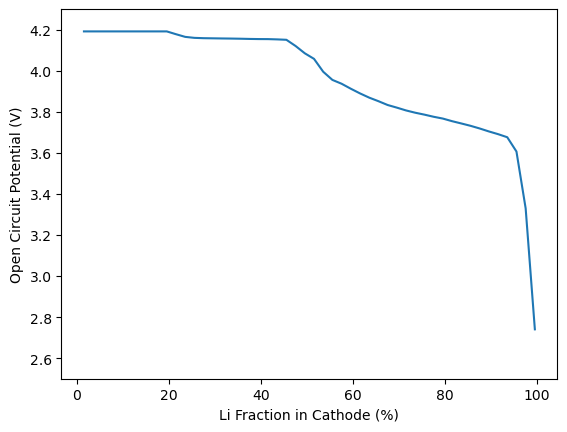

In [7]:
fig, ax = plt.subplots()
ax.plot(100 * X_Li_ca, E_cell_kin)
_ = ax.set(ylim=[2.5, 4.3], xlabel="Li Fraction in Cathode (%)",
           ylabel="Open Circuit Potential (V)")

## Thermodynamic Equilibrium Calculation

For the $i_{app} = 0$ case, we can also calculate the voltage using
thermodynamics. At equilibrium, the net electrochemical potential change of the
reaction must be zero:

\begin{align}\sum_k\nu_k\tilde{\mu}_k = 0\end{align}

where $\tilde{\mu}_k = \mu_k + z_kF\Phi_k$, where, in turn
$\mu_k = \frac{\partial g_k}{\partial n_k}$ is the chemical potential,
$\nu_k$ the net stoichiometric coefficient, $z_k$ the net elementary
charge, and $\Phi_k$ the phase electric potential for species $k$.

From this, we can calculate the equilibrium electric potential difference
$\Delta \Phi_{\rm eq} = \left(\Phi_{\rm elde} - \Phi_{\rm elyte}\right)_{\rm eq}$
as:

\begin{align}\Delta \Phi_{\rm eq} = -\frac{\Delta g_{\rm rxn}}{n_{\rm charge}F}\end{align}

where $\Delta g_{\rm rxn} = \sum_k \nu_k\mu_k$ is the chemical potential of the
reaction and and $n_{\rm charge} = \sum_{k,\,{\rm elde}} \nu_k z_k$ is the net
elementary charge transferred from the electrolyte to the electrode.



In [8]:
# Tic
t0 = time.time()

# Initialize array of OCVs
E_cell_therm = np.zeros_like(X_Li_ca)

for i, X_an in enumerate(X_Li_an):
    # Set anode electrode potential to 0
    anode.X = "Li[anode]:" + str(X_an) + ", V[anode]:" + str(1 - X_an)
    dG_an = anode_interface.delta_gibbs[0]
    n_charge = 1.0
    E_eq_an = -dG_an / n_charge / ct.faraday

    cathode.X = "Li[cathode]:" + str(1.0 - X_an) + ", V[cathode]:" + str(X_an)
    dG_ca = cathode_interface.delta_gibbs[0]
    n_charge = 1.0
    E_eq_ca = -dG_ca / n_charge / ct.faraday

    E_cell_therm[i] = E_eq_ca - E_eq_an

# Toc
t1 = time.time()
print(f"{i:d} cell voltages calculated in {t1 - t0:3.2e} seconds.")

49 cell voltages calculated in 2.11e-02 seconds.


## Plot thermodynamic OCV, and compare to results from kinetic method



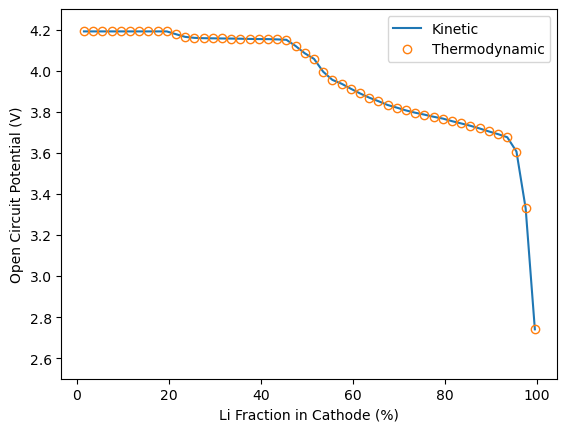

In [9]:
fig, ax = plt.subplots()
ax.plot(100 * X_Li_ca, E_cell_kin, label="Kinetic")
ax.plot(100 * X_Li_ca, E_cell_therm,
        linewidth=0.0, marker="o", markerfacecolor="none", label="Thermodynamic")
ax.set(ylim=[2.5, 4.3], xlabel="Li Fraction in Cathode (%)",
       ylabel="Open Circuit Potential (V)")
ax.legend()
plt.show()

As one would expect, the two approaches give identical results. While both methods are
incredibly fast, the thermodynamic method is roughly 30 times faster.

A large part of this is that the thermodynamic approach is an analytical approach
(i.e. the answer is known from theory), while the kinetic approach relies on the
root-finding fzero method to fit the correct voltage. Note also that the kinetic
method, because of the use of Butler-Volmer kinetics, calculates the thermodynamic
voltage, in order to calculate the overpotential $\eta = \Delta \Phi - \Delta
\Phi_{\rm eq}$.

However, it is at last important to note that, while slower, the kinetic method is of
course more robust, and can be used to find results away from equilibrium. The
thermodynamic method is only applicable at equilibrium (zero current).

